# MNIST Classification: From Underfitting to Overfitting

In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

import matplotlib.pyplot as plt
import numpy as np
from tqdm.notebook import tqdm

# Set device and random seed for reproducibility
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(42)
np.random.seed(42)

print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

Using device: cuda
PyTorch version: 2.5.1


## 1. Data Loading and Preprocessing

In [ ]:
# Data transformations
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # MNIST mean and std
])

# Download and load MNIST dataset. Note that this is a big simplification for the dataset. When we are working with our own data we need to define our dataset and dataloader ourself
full_train_dataset = datasets.MNIST('data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST('data', train=False, transform=transform)

# Split training set into train and validation, we dont use all the images that exist for the mnist dataset
train_size = 50000
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")

# Create data loaders, from the datasets. Each dataset defines how the data should look like and how it returned when calling the loader.
# the dataset defines what the dataset looks like and in what format we want to have the samples. The dataloader takes care of the loading during training and correct devices
batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"Batches per epoch: {len(train_loader)}")

Sample images from training set:


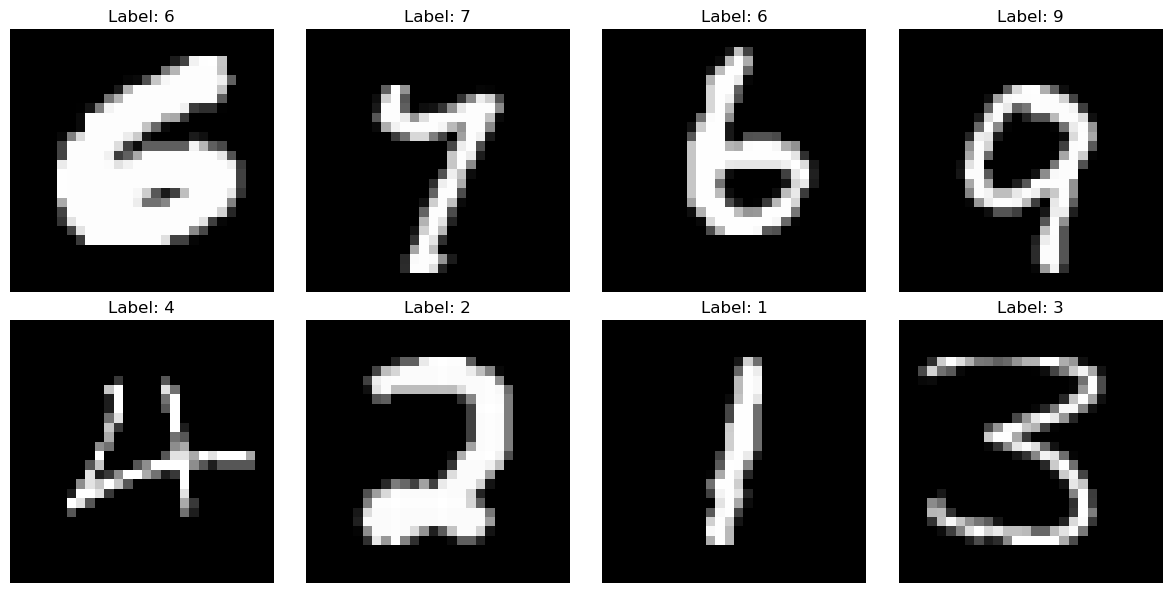


Batch shape: torch.Size([128, 1, 28, 28])
Labels shape: torch.Size([128])


In [16]:
# Visualize some samples
def show_samples(dataset, num_samples=8):
    fig, axes = plt.subplots(2, 4, figsize=(12, 6))
    axes = axes.ravel()
    
    for i in range(num_samples):
        img, label = dataset[i]
        img = img.squeeze()
        
        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(f'Label: {label}')
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

# Show samples from training set
print("Sample images from training set:")
show_samples(train_dataset)

# Check data 

sample_batch = next(iter(train_loader))
images, labels = sample_batch
print(f"\nBatch shape: {images.shape}")
print(f"Labels shape: {labels.shape}")

## 2. Model Definitions

In [17]:
# Define our three models with different complexities

class TooSimpleNet(nn.Module):
    """Very simple model - likely to underfit"""
    def __init__(self):
        super(TooSimpleNet, self).__init__()
        self.fc = nn.Linear(784, 10)  
    
    def forward(self, x):
        x = x.view(x.size(0), -1)  
        return self.fc(x)

class GoodNet(nn.Module):
   
    def __init__(self):
        super(GoodNet, self).__init__()
        self.fc1 = nn.Linear(784, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)
        self.dropout = nn.Dropout(0.3)
    
    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        return self.fc3(x)

class TooComplexNet(nn.Module):
    """Overly complex model - likely to overfit"""
    def __init__(self):
        super(TooComplexNet, self).__init__()
        self.fc1 = nn.Linear(784, 1024)
        self.fc2 = nn.Linear(1024, 512)
        self.fc3 = nn.Linear(512, 256)
        self.fc4 = nn.Linear(256, 128)
        self.fc5 = nn.Linear(128, 64)
        self.fc6 = nn.Linear(64, 10)

    
    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = F.relu(self.fc4(x))
        x = F.relu(self.fc5(x))
        return self.fc6(x)

# Create model instances
models = {
    'TooSimple': TooSimpleNet(),
    'Good': GoodNet(),
    'TooComplex': TooComplexNet()
}

## 2.1 Simple Training Loop Demo

Before we dive into the full training pipeline, let's see a basic training loop in action. This will help you understand the core mechanics and we can compare GPU vs CPU performance.

In [18]:
def simple_training_loop(model, num_epochs=3):
    
    # Create a fresh model instance
    model = model.to(device)
    
    # Define loss function and optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch + 1}/{num_epochs}")
        
        # Training phase
        model.train() 
        total_loss = 0.0
        correct_predictions = 0
        total_samples = 0
        
        # Loop through batches
        for batch_idx, (data, target) in enumerate(train_loader):
            # Move data to device
            data, target = data.to(device), target.to(device)
            
            # Zero the gradients (important!)
            optimizer.zero_grad()
            
            # Forward pass: compute predictions
            outputs = model(data)
            
            # Compute loss
            loss = criterion(outputs, target)
            
            # Backward pass: compute gradients
            loss.backward()
            
            # Update parameter, what we have done manually before
            optimizer.step()
            
            # Track statistics
            total_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_samples += target.size(0)
            correct_predictions += (predicted == target).sum().item()
            
            # Print progress every 100 batches
            if batch_idx % 100 == 0:
                current_loss = total_loss / (batch_idx + 1)
                current_acc = 100.0 * correct_predictions / total_samples
                print(f"  Batch {batch_idx:3d}: Loss = {current_loss:.4f}, Accuracy = {current_acc:.1f}%")
        
        # Calculate epoch statistics
        epoch_loss = total_loss / len(train_loader)
        epoch_acc = 100.0 * correct_predictions / total_samples
        
        print(f"  Epoch {epoch + 1} Summary: Loss = {epoch_loss:.4f}, Accuracy = {epoch_acc:.1f}%")
    
    print(f"\nTraining completed!")
    return model

In [19]:
# Let's run our simple training loop
trained_model = simple_training_loop(GoodNet(), num_epochs=2)


Epoch 1/2
  Batch   0: Loss = 2.3091, Accuracy = 11.7%
  Batch   0: Loss = 2.3091, Accuracy = 11.7%
  Batch 100: Loss = 0.9204, Accuracy = 70.7%
  Batch 100: Loss = 0.9204, Accuracy = 70.7%
  Batch 200: Loss = 0.6720, Accuracy = 79.0%
  Batch 200: Loss = 0.6720, Accuracy = 79.0%
  Batch 300: Loss = 0.5589, Accuracy = 82.6%
  Batch 300: Loss = 0.5589, Accuracy = 82.6%
  Epoch 1 Summary: Loss = 0.4980, Accuracy = 84.5%

Epoch 2/2
  Epoch 1 Summary: Loss = 0.4980, Accuracy = 84.5%

Epoch 2/2
  Batch   0: Loss = 0.2262, Accuracy = 93.0%
  Batch   0: Loss = 0.2262, Accuracy = 93.0%
  Batch 100: Loss = 0.2553, Accuracy = 92.5%
  Batch 100: Loss = 0.2553, Accuracy = 92.5%
  Batch 200: Loss = 0.2539, Accuracy = 92.5%
  Batch 200: Loss = 0.2539, Accuracy = 92.5%
  Batch 300: Loss = 0.2446, Accuracy = 92.8%
  Batch 300: Loss = 0.2446, Accuracy = 92.8%
  Epoch 2 Summary: Loss = 0.2391, Accuracy = 92.9%

Training completed!
  Epoch 2 Summary: Loss = 0.2391, Accuracy = 92.9%

Training completed!


## 3. Training Function with TensorBoard Logging

In [ ]:
def train_model(model, num_epochs=10, learning_rate=0.001):
    
    # Move model to device
    model = model.to(device)
    
    # Loss function and optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    # Training history
    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': []
    }
    
    for epoch in range(num_epochs):
        # Training phase
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0
        
        train_pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Train]', leave=False)
        for _, (data, target) in enumerate(train_pbar):
            data, target = data.to(device), target.to(device)
            
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
            
            # Statistics
            train_loss += loss.item()
            _, predicted = torch.max(output.data, 1)
            train_total += target.size(0)
            train_correct += (predicted == target).sum().item()
            
            # Update progress bar
            train_pbar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'acc': f'{100.*train_correct/train_total:.2f}%'
            })
        
        # Validation phase
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            val_pbar = tqdm(val_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Val]', leave=False)
            for data, target in val_pbar:
                data, target = data.to(device), target.to(device)
                output = model(data)
                loss = criterion(output, target)
                
                val_loss += loss.item()
                _, predicted = torch.max(output.data, 1)
                val_total += target.size(0)
                val_correct += (predicted == target).sum().item()
                
                val_pbar.set_postfix({
                    'loss': f'{loss.item():.4f}',
                    'acc': f'{100.*val_correct/val_total:.2f}%'
                })
        
        # Calculate epoch metrics
        train_loss_avg = train_loss / len(train_loader)
        train_acc = 100. * train_correct / train_total
        val_loss_avg = val_loss / len(val_loader)
        val_acc = 100. * val_correct / val_total
        
        # Store history
        history['train_loss'].append(train_loss_avg)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss_avg)
        history['val_acc'].append(val_acc)
        
        # Print epoch results
        if (epoch + 1) % 5 == 0:
            print(f'Epoch {epoch+1:2d}: '
                  f'Train Loss: {train_loss_avg:.4f}, Train Acc: {train_acc:.2f}% | '
                  f'Val Loss: {val_loss_avg:.4f}, Val Acc: {val_acc:.2f}%')
    
    print()
    
    return model, history

## 4. Train All Models

In [21]:
# Train all models
from models import TooComplexNet, ConvNet
models = {
    'TooSimple': TooSimpleNet(),
    'Good': GoodNet(),
    'TooComplex': TooComplexNet(),
    'ConvNet': ConvNet()
}
trained_models = {}
training_histories = {}
log_dirs = {}

# Training parameters
num_epochs = 25
learning_rate = 0.001

for name, model in models.items():
    print(f"\n{'='*60}")
    print(f"Training {name} Model")
    
    trained_model, history = train_model(
        model, num_epochs=num_epochs, learning_rate=learning_rate
    )
    
    trained_models[name] = trained_model
    training_histories[name] = history

print("\n" + "="*60)
print("ALL MODELS TRAINED!")
print("="*60)


Training TooSimple Model


Epoch 1/25 [Train]:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 1/25 [Val]:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch  1: Train Loss: 0.4576, Train Acc: 87.27% | Val Loss: 0.3324, Val Acc: 90.40%


Epoch 2/25 [Train]:   0%|          | 0/391 [00:00<?, ?it/s]

...

Epoch 24/25 [Train]:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 24/25 [Val]:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 25/25 [Train]:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 25/25 [Val]:   0%|          | 0/79 [00:00<?, ?it/s]



ALL MODELS TRAINED!


## 5. Analyze Training Results

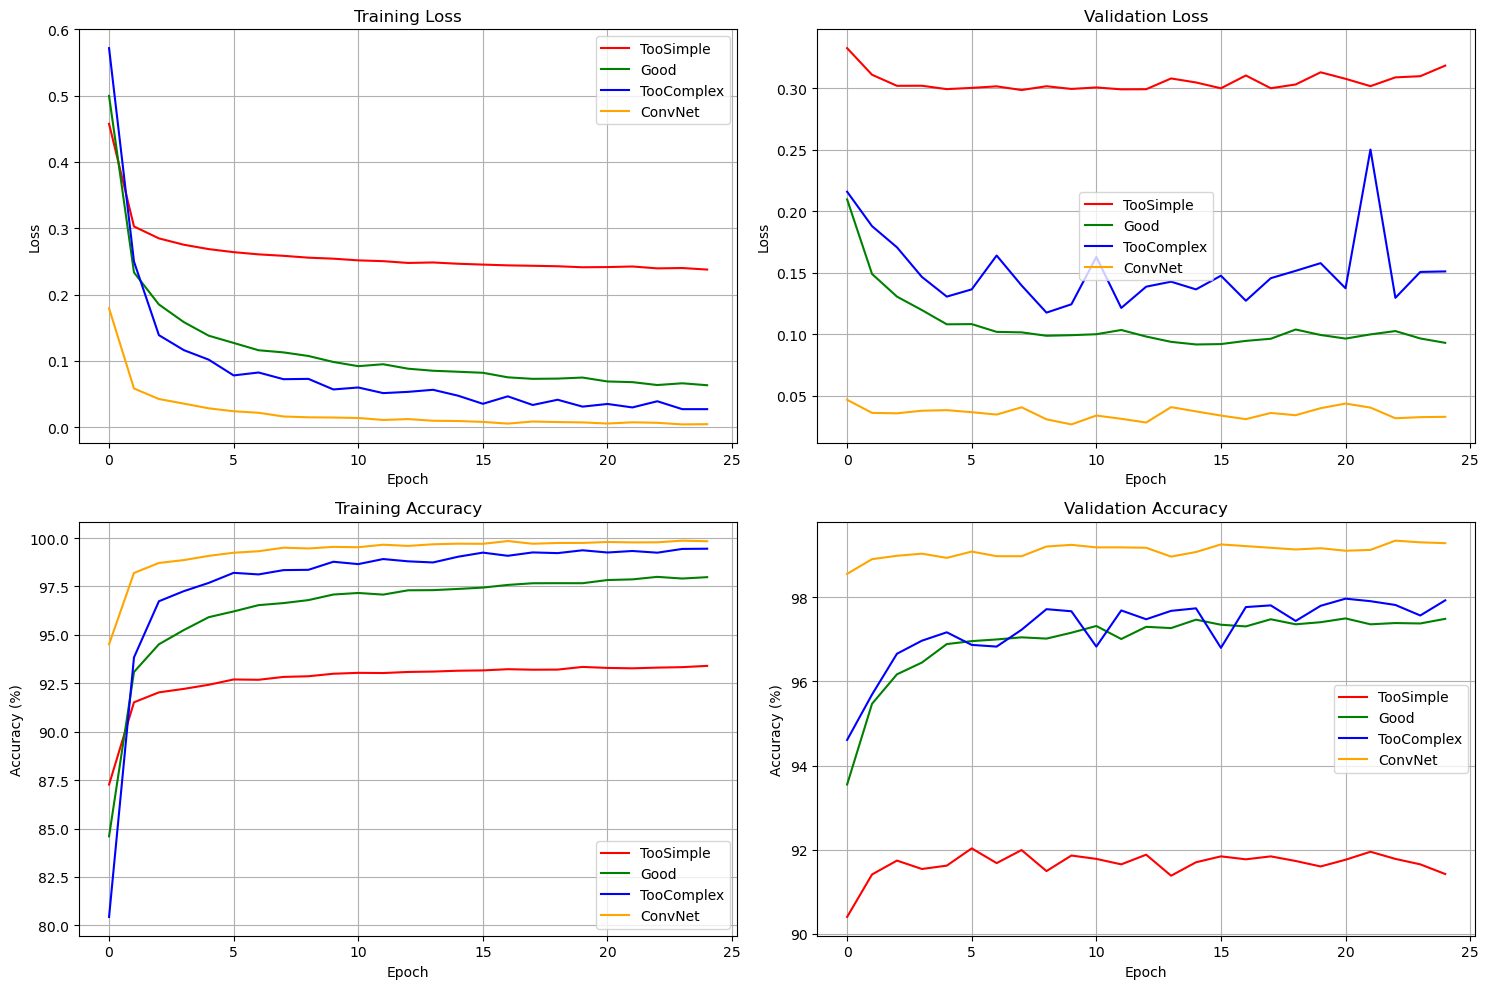

In [22]:
# Plot training curves
def plot_training_curves(histories):
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Dynamic color assignment for all models
    colors = {'TooSimple': 'red', 'Good': 'green', 'TooComplex': 'blue', 'ConvNet': 'orange'}
    default_colors = ['purple', 'brown', 'pink', 'gray', 'olive', 'cyan']
    
    # Assign colors to any additional models not in the predefined list
    color_idx = 0
    for name in histories.keys():
        if name not in colors:
            colors[name] = default_colors[color_idx % len(default_colors)]
            color_idx += 1
    
    # Training Loss
    axes[0, 0].set_title('Training Loss')
    for name, history in histories.items():
        axes[0, 0].plot(history['train_loss'], label=name, color=colors[name])
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True)
    
    # Validation Loss
    axes[0, 1].set_title('Validation Loss')
    for name, history in histories.items():
        axes[0, 1].plot(history['val_loss'], label=name, color=colors[name])
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Loss')
    axes[0, 1].legend()
    axes[0, 1].grid(True)
    
    # Training Accuracy
    axes[1, 0].set_title('Training Accuracy')
    for name, history in histories.items():
        axes[1, 0].plot(history['train_acc'], label=name, color=colors[name])
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Accuracy (%)')
    axes[1, 0].legend()
    axes[1, 0].grid(True)
    
    # Validation Accuracy
    axes[1, 1].set_title('Validation Accuracy')
    for name, history in histories.items():
        axes[1, 1].plot(history['val_acc'], label=name, color=colors[name])
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Accuracy (%)')
    axes[1, 1].legend()
    axes[1, 1].grid(True)
    
    plt.tight_layout()
    plt.show()

# Plot the curves
plot_training_curves(training_histories)

## 7. Visualize Model Predictions

## 6. Test Set Evaluation

In [23]:
# Evaluate on test set
def evaluate_model(model, test_loader, model_name):
    model.eval()
    test_loss = 0
    correct = 0
    total = 0
    
    criterion = nn.CrossEntropyLoss()
    
    with torch.no_grad():
        for data, target in tqdm(test_loader, desc=f'Testing {model_name}'):
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss += criterion(output, target).item()
            _, predicted = torch.max(output.data, 1)
            total += target.size(0)
            correct += (predicted == target).sum().item()
    
    test_loss /= len(test_loader)
    test_acc = 100. * correct / total
    
    return test_loss, test_acc

# Test all models
print("Test Set Results:")
print("=" * 50)

test_results = {}
for name, model in trained_models.items():
    test_loss, test_acc = evaluate_model(model, test_loader, name)
    test_results[name] = {'loss': test_loss, 'accuracy': test_acc}
    
    print(f"{name:12}: Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.2f}%")

# Compare with validation results
print("\nValidation vs Test Comparison:")
print("=" * 60)
for name in trained_models.keys():
    val_acc = training_histories[name]['val_acc'][-1]
    test_acc = test_results[name]['accuracy']
    
    print(f"{name:12}: Val: {val_acc:.2f}%, Test: {test_acc:.2f}%")

Test Set Results:


Testing TooSimple:   0%|          | 0/79 [00:00<?, ?it/s]

TooSimple   : Test Loss: 0.2872, Test Accuracy: 92.24%


Testing Good:   0%|          | 0/79 [00:00<?, ?it/s]

Good        : Test Loss: 0.0765, Test Accuracy: 97.83%


Testing TooComplex:   0%|          | 0/79 [00:00<?, ?it/s]

TooComplex  : Test Loss: 0.1580, Test Accuracy: 97.91%


Testing ConvNet:   0%|          | 0/79 [00:00<?, ?it/s]

ConvNet     : Test Loss: 0.0279, Test Accuracy: 99.40%

Validation vs Test Comparison:
TooSimple   : Val: 91.42%, Test: 92.24%
Good        : Val: 97.49%, Test: 97.83%
TooComplex  : Val: 97.93%, Test: 97.91%
ConvNet     : Val: 99.29%, Test: 99.40%
